# 3. Surface Defect Classification with a CNN
### Level: Intermediate-Advanced | Data: Image (machine vision camera) | Task: Supervised multi-class classification

**Industrial context.** Inline cameras photograph every part on the line - steel strip, machined
surfaces, castings, PCBs. A vision model classifies each image as OK or as a specific defect type
so bad parts are rejected (and the defect type tells engineers *which* upstream process drifted).

**What you'll learn**

* Generating synthetic "brushed metal" images with 3 defect types: **scratch**, **pit**, **crack**
* Building a small convolutional neural network (CNN) in Keras
* Training with validation, reading a confusion matrix, and inspecting the model's mistakes
* Why transfer learning is the practical choice for real data

**Requirements:** `numpy scipy matplotlib tensorflow scikit-learn` (CPU is fine - trains in ~1 minute)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import tensorflow as tf
from tensorflow import keras

rng = np.random.default_rng(0)
tf.random.set_seed(0)
IMG = 64
CLASSES = ['ok', 'scratch', 'pit', 'crack']

I0000 00:00:1783549743.279746      11 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 1. Generate synthetic inspection images

Base texture: horizontal "brushed metal" (smoothed noise + faint banding) with random
brightness/contrast per image, so the model can't cheat on global statistics.

* **scratch**: bright thin straight line at a random angle
* **pit**: a few small dark blobs
* **crack**: dark meandering random-walk path

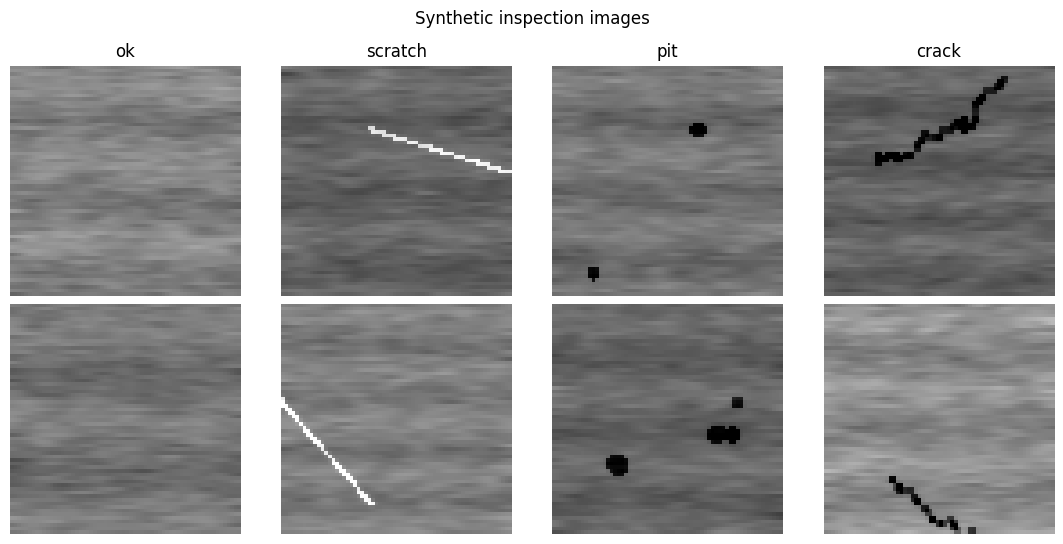

In [2]:
def base_texture():
    img = rng.normal(0.5, 0.12, (IMG, IMG))
    img = gaussian_filter(img, sigma=(0.5, 2.5))                 # horizontal brushing
    img += 0.05 * np.sin(np.linspace(0, rng.uniform(4, 9)*np.pi, IMG))[:, None]  # faint banding
    img = img * rng.uniform(0.85, 1.15) + rng.uniform(-0.06, 0.06)
    return img

def add_scratch(img):
    x0, y0 = rng.uniform(5, IMG-5, 2)
    ang = rng.uniform(0, np.pi)
    length = rng.uniform(25, 55)
    n = 200
    xs = (x0 + np.cos(ang)*np.linspace(-length/2, length/2, n)).astype(int)
    ys = (y0 + np.sin(ang)*np.linspace(-length/2, length/2, n)).astype(int)
    m = (xs >= 0) & (xs < IMG) & (ys >= 0) & (ys < IMG)
    img[ys[m], xs[m]] += rng.uniform(0.35, 0.6)
    return gaussian_filter(img, 0.4)

def add_pits(img):
    yy, xx = np.mgrid[0:IMG, 0:IMG]
    for _ in range(rng.integers(2, 5)):
        cy, cx = rng.uniform(6, IMG-6, 2)
        r = rng.uniform(1.5, 3.5)
        img[(yy-cy)**2 + (xx-cx)**2 < r**2] -= rng.uniform(0.3, 0.5)
    return gaussian_filter(img, 0.4)

def add_crack(img):
    y, x = rng.uniform(10, IMG-10, 2)
    drift = rng.uniform(-1, 1)
    for _ in range(rng.integers(40, 80)):
        y += rng.normal(drift, 0.8); x += rng.normal(1.0, 0.6)
        yi, xi = int(y), int(x)
        if 0 <= yi < IMG and 0 <= xi < IMG:
            img[max(0, yi-1):yi+1, max(0, xi-1):xi+1] -= rng.uniform(0.25, 0.45)
    return gaussian_filter(img, 0.4)

DEFECT_FNS = {0: lambda im: im, 1: add_scratch, 2: add_pits, 3: add_crack}

def make_image(label):
    img = DEFECT_FNS[label](base_texture())
    return np.clip(img, 0, 1).astype(np.float32)

fig, axes = plt.subplots(2, 4, figsize=(11, 5.5))
for j, name in enumerate(CLASSES):
    for i in range(2):
        axes[i, j].imshow(make_image(j), cmap='gray', vmin=0, vmax=1)
        axes[i, j].set_axis_off()
        if i == 0: axes[i, j].set_title(name)
plt.suptitle('Synthetic inspection images'); plt.tight_layout(); plt.show()

## 2. Build the dataset

600 training and 160 validation images, balanced across the 4 classes, shape `(N, 64, 64, 1)`.
In a real project you would read image files from disk (`keras.utils.image_dataset_from_directory`)
and add **augmentation** - flips, small rotations, brightness jitter. Augmentation is usually worth
several percent of accuracy on real inspection data because it teaches the model the invariances
of your camera setup.

In [3]:
def make_dataset(n_per_class, seed):
    global rng
    rng = np.random.default_rng(seed)
    labels = np.repeat(np.arange(4), n_per_class)
    rng.shuffle(labels)
    images = np.stack([make_image(l) for l in labels])[..., None]   # (N, 64, 64, 1)
    return images, labels

X_train, y_train = make_dataset(150, seed=1)   # 600 images
X_val,   y_val   = make_dataset(40,  seed=2)   # 160 images
print('train:', X_train.shape, ' val:', X_val.shape)

train: (600, 64, 64, 1)  val: (160, 64, 64, 1)


## 3. A small CNN

Three conv blocks (conv -> ReLU -> max-pool) then a global-average-pool head.
About 30k parameters - deliberately small since the task and dataset are small.
`GlobalAveragePooling2D` makes the head independent of input resolution.

> **Practical note:** we deliberately leave out `BatchNormalization` here. With only 600 training
> images, BN's moving statistics are poorly estimated, so the model can look great in training
> (which uses batch statistics) yet collapse at inference (which uses the moving averages).
> On small datasets, skip BN or lower its `momentum`.

In [4]:
def build_cnn(n_classes=4):
    return keras.Sequential([
        keras.layers.Input((IMG, IMG, 1)),
        keras.layers.Conv2D(16, 3, padding='same', activation='relu'), keras.layers.MaxPooling2D(),
        keras.layers.Conv2D(32, 3, padding='same', activation='relu'), keras.layers.MaxPooling2D(),
        keras.layers.Conv2D(64, 3, padding='same', activation='relu'), keras.layers.MaxPooling2D(),
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(n_classes, activation='softmax'),
    ])

model = build_cnn()
model.compile(optimizer=keras.optimizers.Adam(2e-3),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,556 (92.02 KB)

 Trainable params: 23,556 (92.02 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                    epochs=10, batch_size=32, verbose=2)

Epoch 1/10


19/19 - 2s - 88ms/step - accuracy: 0.2467 - loss: 1.3924 - val_accuracy: 0.2500 - val_loss: 1.3861


Epoch 2/10


19/19 - 1s - 42ms/step - accuracy: 0.2867 - loss: 1.3833 - val_accuracy: 0.2500 - val_loss: 1.3715


Epoch 3/10


...

19/19 - 1s - 43ms/step - accuracy: 0.6617 - loss: 0.6681 - val_accuracy: 0.7625 - val_loss: 0.6523


Epoch 9/10


19/19 - 1s - 47ms/step - accuracy: 0.7117 - loss: 0.6100 - val_accuracy: 0.8313 - val_loss: 0.5977


Epoch 10/10


19/19 - 1s - 63ms/step - accuracy: 0.7067 - loss: 0.5888 - val_accuracy: 0.8438 - val_loss: 0.5595


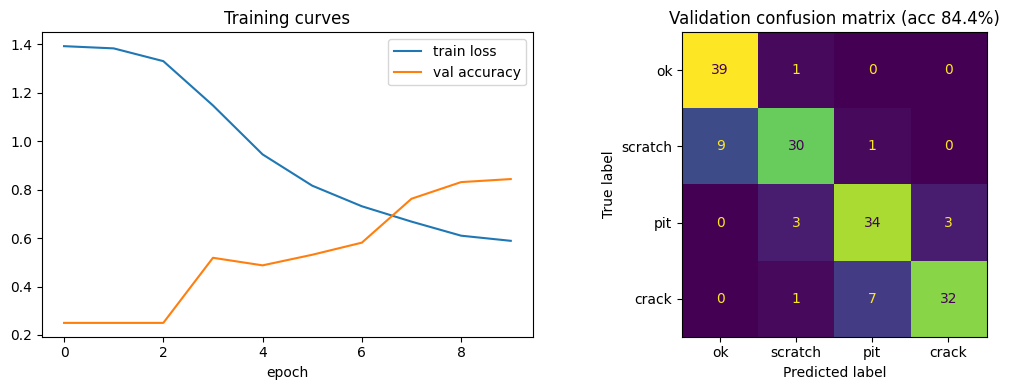

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay

preds = model.predict(X_val, verbose=0).argmax(1)
acc = (preds == y_val).mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history['loss'], label='train loss')
axes[0].plot(history.history['val_accuracy'], label='val accuracy', color='tab:orange')
axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].set_title('Training curves')
ConfusionMatrixDisplay.from_predictions(y_val, preds, display_labels=CLASSES,
                                        ax=axes[1], colorbar=False)
axes[1].set_title(f'Validation confusion matrix (acc {acc:.1%})')
plt.tight_layout(); plt.show()

## 4. Inspect the mistakes

Always look at misclassified images. On real lines this step regularly reveals labeling errors,
camera issues, or defect classes that genuinely overlap (a shallow crack looks like a scratch).

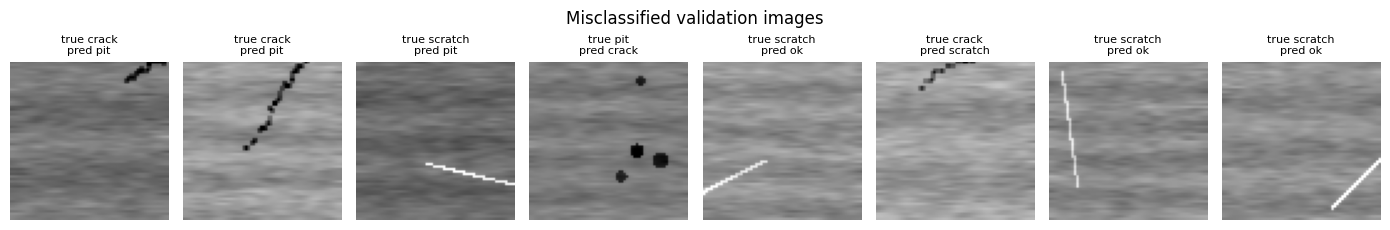

In [7]:
wrong = np.where(preds != y_val)[0]
show = wrong[:8] if len(wrong) else np.arange(8)   # if perfect, show sample predictions instead
fig, axes = plt.subplots(1, len(show), figsize=(14, 2.4))
for ax, i in zip(np.atleast_1d(axes), show):
    ax.imshow(X_val[i, :, :, 0], cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'true {CLASSES[y_val[i]]}\npred {CLASSES[preds[i]]}', fontsize=8)
    ax.set_axis_off()
plt.suptitle('Misclassified validation images' if len(wrong) else 'No errors - sample predictions')
plt.tight_layout(); plt.show()

## 5. Takeaways and next steps

* A tiny CNN saturates this synthetic task; real defect data is harder mainly because of *label scarcity and class imbalance*, not model capacity.
* **Transfer learning is the industrial default:** replace the CNN with a pretrained backbone, e.g. `keras.applications.EfficientNetB0(weights='imagenet', include_top=False)` (or a pretrained ResNet-18 in PyTorch), add a small head for your 4 classes, and fine-tune. With only ~100 labeled images per class this typically beats any model trained from scratch.
* Class imbalance (OK images vastly outnumber defects) is handled with `class_weight` in `fit()`, weighted sampling, or focal loss.
* **Real data:** NEU Surface Defect Database (steel), Severstal steel defects (Kaggle), DAGM 2007.
* Next notebook: what if you *don't have labeled defect images at all?* Unsupervised visual anomaly detection.